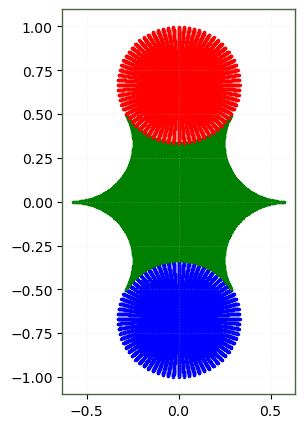

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('/home/lplaja/.matplotlib/stylelib/obsidian.mplstyle')

x_p = []
y_p = []
with open("grid_p.txt", "r") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        ix,iy= map(complex, line.split())
        x_p.append(np.real(ix))
        y_p.append(np.real(iy))

x_m = []
y_m = []
with open("grid_m.txt", "r") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        ix,iy= map(complex, line.split())
        x_m.append(np.real(ix))
        y_m.append(np.real(iy))
x_c = []
y_c = []
with open("grid_c.txt", "r") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        ix,iy= map(complex, line.split())
        x_c.append(np.real(ix))
        y_c.append(np.real(iy))

fig,ax=plt.subplots(1,1,figsize=(3,5))

ax.scatter(x_m,y_m, s=2, c='b')
ax.scatter(x_c,y_c, s=2, c='g')
ax.scatter(x_p,y_p, s=2, c='r')

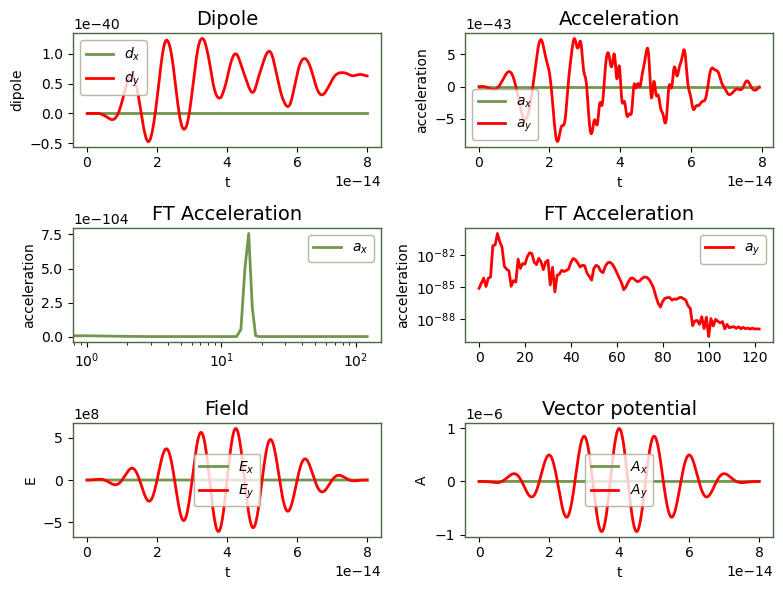

In [3]:

t = []
t_dipole=[]
dipole_x = []
dipole_y = []
E_x = []
E_y = []
A_x = []
A_y = []

with open("dipole_polar.txt", "r") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        it, ix, iy= map(complex, line.split())
        t_dipole.append(np.real(it))
        dipole_x.append(ix)
        dipole_y.append(iy)
    
with open("field.txt", "r") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        it, ix, iy, jx, jy= map(complex, line.split())
        t.append(np.real(it))
        E_x.append(ix)
        E_y.append(iy)
        A_x.append(jx)
        A_y.append(jy)
        
accel_x=np.gradient(np.gradient(np.real(dipole_x)))
accel_y=np.gradient(np.gradient(np.real(dipole_y)))
accel_x=accel_x[2:-3]
accel_y=accel_y[2:-3]

nfilter=accel_x.shape[0]//5
i_filter=np.linspace(0,nfilter,nfilter)
filter=np.ones(accel_x.shape[0])
filter[-nfilter:]*=np.exp(-i_filter**2/10)

#accel_x*=filter
#accel_y*=filter

FT_npts=2*accel_x.shape[0]//8
FT_accel_x=np.fft.fft(accel_x)[:FT_npts]
FT_accel_y=np.fft.fft(accel_y)[:FT_npts]


fig, ax=plt.subplots(3,2, figsize=(8,6))

# ax[0,0].plot(t_dipole[2:-3], np.real(dipole_x[2:-3]), label="$d_x$")
# ax[0,0].plot(t_dipole[2:-3], np.real(dipole_y[2:-3]), label="$d_y$", c='r')
# ax[0,0].set_xlabel("t")
# ax[0,0].set_ylabel("dipole")
# ax[0,0].set_title("Dipole")
# ax[0,0].legend()
# ax[0,0].grid(False)

ax[0,0].plot(t_dipole, np.real(dipole_x), label="$d_x$")
ax[0,0].plot(t_dipole, np.real(dipole_y), label="$d_y$", c='r')
ax[0,0].set_xlabel("t")
ax[0,0].set_ylabel("dipole")
ax[0,0].set_title("Dipole")
ax[0,0].legend()
ax[0,0].grid(False)

ax[0,1].plot(t_dipole[2:-3], np.real(accel_x), label="$a_x$")
ax[0,1].plot(t_dipole[2:-3], np.real(accel_y), label="$a_y$", c='r')
ax[0,1].set_xlabel("t")
ax[0,1].set_ylabel("acceleration")
ax[0,1].set_title("Acceleration")
ax[0,1].legend()
ax[0,1].grid(False)

ax[1,0].semilogx(np.abs(FT_accel_x)**2, label="$a_x$")
ax[1,0].set_xlabel("")
ax[1,0].set_ylabel("acceleration")
ax[1,0].set_title("FT Acceleration")
ax[1,0].legend()
ax[1,0].grid(False)

ax[1,1].semilogy(np.abs(FT_accel_y)**2, label="$a_y$", c='r')
ax[1,1].set_xlabel("")
ax[1,1].set_ylabel("acceleration")
ax[1,1].set_title("FT Acceleration")
ax[1,1].legend()
ax[1,1].grid(False)
#ax[1,1].set_ylim([1e-47, 1e-38])


ax[2,0].plot(t, np.real(E_x), label="$E_x$")
ax[2,0].plot(t, np.real(E_y), label="$E_y$", c='r')
ax[2,0].set_xlabel("t")
ax[2,0].set_ylabel("E")
ax[2,0].set_title("Field")
ax[2,0].legend()
ax[2,0].grid(False)

ax[2,1].plot(t, np.real(A_x), label="$A_x$")
ax[2,1].plot(t, np.real(A_y), label="$A_y$", c='r')
ax[2,1].set_xlabel("t")
ax[2,1].set_ylabel("A")
ax[2,1].set_title("Vector potential")
ax[2,1].legend()
ax[2,1].grid(False)


plt.tight_layout()

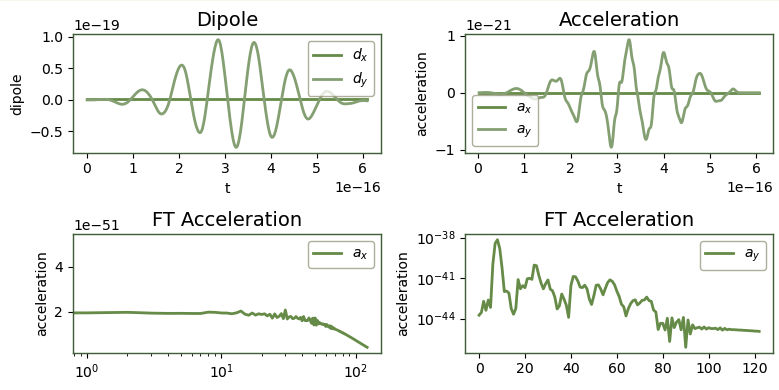

In [ ]:
print(Efiele)